# ATMS 523 - FINAL PROJECT

## The Identification of Moisture Pathways Associated with Widespread Extreme Precipitation in the Great Lakes

### 1. Introduction 

This project investigates the role of moisture flux (MF) and moisture flux convergence (MFC) in controlling widespread extreme precipitation in the Great Lakes region using ERA5 reanalysis data and modern data-driven techniques.

### 2. Objectives

The main objectives of this study are to:

1. Select widespread extreme precipitation events in Domain 1 using:

- A daily precipitation intensity threshold based on the 95th percentile.
- A minimum precipitation area based on the median of precipitation grid points.

2. Compute and analyze:

- Moisture Flux (MF) and Moisture Flux Convergence (MFC) at 850 hPa and 500 hPa over Domain 2 using ERA5.
- Empirical Orthogonal Function (EOF) analysis to identify dominant modes of moisture transport variability.

3. Quantify the relationship between moisture transport and precipitation using:
- Polynomial Regression
- Random Forest Regression

4. Apply SHAP (SHapley Additive exPlanations) to interpret the contribution of predictors to widespread extreme precipitation

### 3. Study Domain and Data

1. Spatial Domains

- Domain 1 (Extreme precipitation selection): 41°–49°N, 76°–92°W
- Domain 2 (Moisture transport analysis): 37°–52°N, 70°–105°W

<img src="/data/keeling/a/deffip2/ATMS_523/FINAL_PROJECT/StudyArea.png" width="500">


2. Period and Resolution

- Analysis period: 2000–2020
- Temporal resolution: Hourly → Aggregated to Daily
- Pressure Levels: 850 hPa and 500 hPa

3. Variables

Specific humidity (q), zonal wind (u), meridional wind (v), total precipitation (tp)

4. Data Source
- ERA5 hourly data on single levels DOI:10.24381/cds.adbb2d47
- ERA5 hourly data on pressure levels DOI: 10.24381/cds.bd0915c6

In [1]:
import xarray as xr
import dask.array as da
import numpy as np
import pandas as pd
import glob
import os
import metpy.calc as mpcalc
from eofs.xarray import Eof

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import shap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, HoverTool

## 1. Data Loading and Preprocessing

We are implementing the xarray and chunk from Module 2 to loading the ERA5 data from cloud anonymously. Hourly precipitation is trimmed for Domain 1 and aggregated into daily precipitation. This data then stored in the local directory for computation efficiency.

In [2]:
store = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
ds = xr.open_zarr(
    store,
    consolidated=True,
    storage_options={"token": "anon"},
    chunks={
        "time": 240,
        "latitude": 80,
        "longitude": 80
    },
)

/tmp/ipykernel_841702/2057074842.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 80. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(
/tmp/ipykernel_841702/2057074842.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 80. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


### 1.1 Data preparation

In [3]:
# Restrict to the period of interest
ds = ds.sel(time=slice("2000-01-01", "2020-12-31"))

In [2]:
# Domain 1 (Great Lakes)
domain1 = dict(
    latitude=slice(49, 41),
    longitude=slice(268, 284)
)

In [ ]:
# Precip untuk event selection (Domain 1)
ds_tp_d1 = ds["total_precipitation"].sel(**domain1)

In [ ]:
outdir = "/data/keeling/a/deffip2/ATMS_523/FINAL_PROJECT/DATA"
os.makedirs(outdir, exist_ok=True)

# Daily total precipitation
ds_tp_daily_d1 = ds_tp_d1.resample(time="1D").sum()


In [ ]:
# Only do this once!
fn_tp_d1 = os.path.join(outdir, "tp_daily_domain1_2000-2020.nc")
ds_tp_daily_d1.to_netcdf(fn_tp_d1)

## 2. Extreme Precipitation Event Selection (Domain 1)

In this second step, we intend to select widespread extreme precipitation event by choosing events that can exceed precipitation intensity threshold (intensity filtering) and minimum grid points threshold (area filtering). 

<img src="/data/keeling/a/deffip2/ATMS_523/FINAL_PROJECT/ex wx filtering.png" width="500">

In [3]:
ds_tp = xr.open_dataset("/data/keeling/a/deffip2/ATMS_523/FINAL_PROJECT/DATA/tp_daily_domain1_2000-2020.nc")

In [4]:
tp_daily = ds_tp["total_precipitation"]

# m to mm
tp_daily_mm = tp_daily * 1000.0

### 2.1 Step 1: Daily extreme precipitation intensity filtering (p95)

In [5]:
vals = tp_daily_mm.load().values.ravel()
vals = vals[~np.isnan(vals)]

count, bins_count = np.histogram(tp_daily_mm\
                        .dropna('time'), bins=50)

pdf = count / sum(count)
cdf = np.cumsum(pdf)

percentile = tp_daily_mm.quantile(0.95)
percentile = float(percentile.values)
rounded_value_95th = np.round(percentile, 4 - int(np.floor(np.log10(abs(percentile)))) - 1)

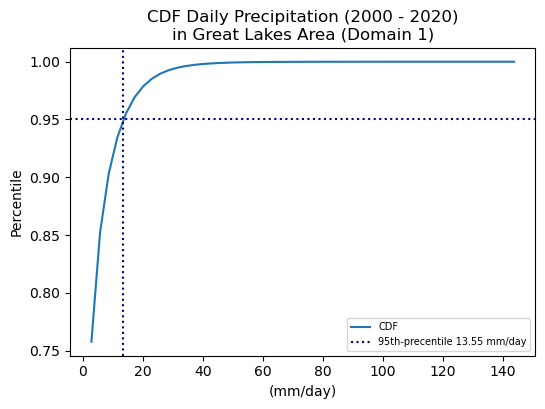

In [6]:
plt.figure(figsize=(6,4))
plt.plot(bins_count[1:], cdf, label="CDF")
plt.title('CDF Daily Precipitation (2000 - 2020)\nin Great Lakes Area (Domain 1)', fontsize=12, ha='center')
plt.xlabel('(mm/day)')
plt.ylabel('Percentile')
plt.axhline(y=.95, color='navy', linestyle=':',label=f'95th-precentile {rounded_value_95th} mm/day')
plt.axvline(x=percentile, color='navy', linestyle=':')
plt.legend(fontsize=7)

### 2.2 Step 2: Spatial Extent of Extreme Precipitation Grid Points (Median)

The second step of event selection filtering is considering the minimum daily precipitation grid points by using median value of extreme events grid points as a threshold to justify widespread events.

In [7]:
grid_extreme_mask = tp_daily_mm > percentile

extreme_counts = grid_extreme_mask.sum(dim=["latitude", "longitude"])
extreme_counts_nonzero = extreme_counts.where(extreme_counts > 0)

area_count_thresh = extreme_counts_nonzero.median(dim="time")


### 2.3 Step 3: Selecting the extreme precipitation events

The selected dates are exported to excel file for data q, u, and v data download from ERA5 google cloud storage because zarr give more computation time (a python file to automatically download the ERA5 data is attached to this github). The downloaded data then merge into one file for 500 hPa and 850 hPa.

In [8]:
event_mask = extreme_counts >= area_count_thresh
event_days = tp_daily_mm["time"].where(event_mask, drop=True)

In [ ]:
event_dates = pd.to_datetime(event_days.values)
df_events = pd.DataFrame({"date": pd.to_datetime(event_days.values)})
out_excel = "/data/keeling/a/deffip2/ATMS_523/FINAL_PROJECT/event_days_2000_2020.xlsx"
df_events.to_excel(out_excel, index=False)


In [ ]:
#Only do this once!

indir = "/data/keeling/a/deffip2/a/ATMS523/MOIST_PER_YEAR"

# 500 hPa pressure level data
files_500 = sorted(glob.glob(os.path.join(indir, "*_500hPa.nc")))

ds_500 = xr.open_mfdataset(
    files_500,
    combine="by_coords",
    parallel=True,
    engine="netcdf4"
)

ds_500.to_netcdf("/data/keeling/a/deffip2/a/ATMS523/MOIST_PER_YEAR/era5_moist_events_2000_2020_500hPa.nc")

In [ ]:
#Only do this once!

# 850 hPa pressure level data
files_850 = sorted(glob.glob(os.path.join(indir, "*_850hPa.nc")))

ds_850 = xr.open_mfdataset(
    files_850,
    combine="by_coords",
    parallel=True,
    engine="netcdf4"
)

ds_850.to_netcdf("/data/keeling/a/deffip2/a/ATMS523/MOIST_PER_YEAR/era5_moist_events_2000_2020_850hPa.nc")

## 3. Moisture Flux and Moisture Flux Convergence Calculation



In [10]:
ds_moist_500 = xr.open_dataset("/data/keeling/a/deffip2/a/ATMS523/MOIST_PER_YEAR/era5_moist_events_2000_2020_500hPa.nc")
ds_moist_850 = xr.open_dataset("/data/keeling/a/deffip2/a/ATMS523/MOIST_PER_YEAR/era5_moist_events_2000_2020_850hPa.nc")

### 3.1 Moisture Flux

Moisture flux components are calculated as:

- Zonal moisture flux:
\[
\begin{aligned}
MF_{u,p} &= q_p \, u_p \times 1000
\end{aligned}
\]
- Meridional moisture flux:
\[
\begin{aligned}
MF_{v,p} &= q_p \, v_p \times 1000
\end{aligned}
\]
- Moisture Flux Magnitudo:
\[
\begin{aligned}
MF_p = \sqrt{MF_{u,p}^2 + MF_{v,p}^2}
\end{aligned}
\]

Moisture flux convergence (MFC):
$$
\begin{aligned}
\mathrm{qDiv}_p &= - q_p \, (\nabla \cdot \mathbf{V}_p), \\[6pt]

\mathrm{Adv}_p
&= - \mathbf{V}_p \cdot \nabla q_p \\
&= - \left(
u_p \frac{\partial q_p}{\partial x}
+ v_p \frac{\partial q_p}{\partial y}
\right), \\[6pt]

\mathrm{MFC}_p &= \mathrm{Adv}_p + \mathrm{qDiv}_p
\end{aligned}
$$


All calculations are performed using MetPy, ensuring unit consistency and proper grid spacing based on latitude–longitude geometry.

In [11]:
MF_u_850 = (ds_moist_850.q * ds_moist_850.u)*1000
MF_v_850 = (ds_moist_850.q * ds_moist_850.v)*1000
MF_850 = np.sqrt(MF_u_850**2 + MF_v_850**2)

MF_u_500 = (ds_moist_500.q * ds_moist_500.u)*1000
MF_v_500 = (ds_moist_500.q * ds_moist_500.v)*1000
MF_500 = np.sqrt(MF_u_500**2 + MF_v_500**2)

### 3.2 Moisture Flux Convergence

In [12]:
# divergence term
div_500 = -mpcalc.divergence(ds_moist_500.u, ds_moist_500.v)
qdiv_500 = (ds_moist_500.q)*1000 *div_500

div_850 = -mpcalc.divergence(ds_moist_850.u, ds_moist_850.v)
qdiv_850 = (ds_moist_850.q)*1000 *div_850

# q advection term
adv_500 = mpcalc.advection((ds_moist_500.q)*1000, ds_moist_500.u, ds_moist_500.v)
adv_850 = mpcalc.advection((ds_moist_850.q)*1000, ds_moist_850.u, ds_moist_850.v)

# MFC = divergence + advection
MFC_500 = adv_500 + qdiv_500
MFC_850 = adv_850 + qdiv_850

/tmp/ipykernel_2288418/1545663892.py:9: UserWarning: Vertical dimension number not found. Defaulting to (..., Z, Y, X) order.
  adv_500 = mpcalc.advection((ds_moist_500.q)*1000, ds_moist_500.u, ds_moist_500.v)
/tmp/ipykernel_2288418/1545663892.py:10: UserWarning: Vertical dimension number not found. Defaulting to (..., Z, Y, X) order.
  adv_850 = mpcalc.advection((ds_moist_850.q)*1000, ds_moist_850.u, ds_moist_850.v)


In [13]:
MF_u_500_comp = MF_u_500.mean(dim='time')
MF_v_500_comp = MF_v_500.mean(dim='time')
MF_u_850_comp = MF_u_850.mean(dim='time')
MF_v_850_comp = MF_v_850.mean(dim='time')

MF_500_comp = MF_500.mean(dim='time')
MF_850_comp = MF_850.mean(dim='time')
MFC_500_comp = MFC_500.mean(dim='time')
MFC_850_comp = MFC_850.mean(dim='time')

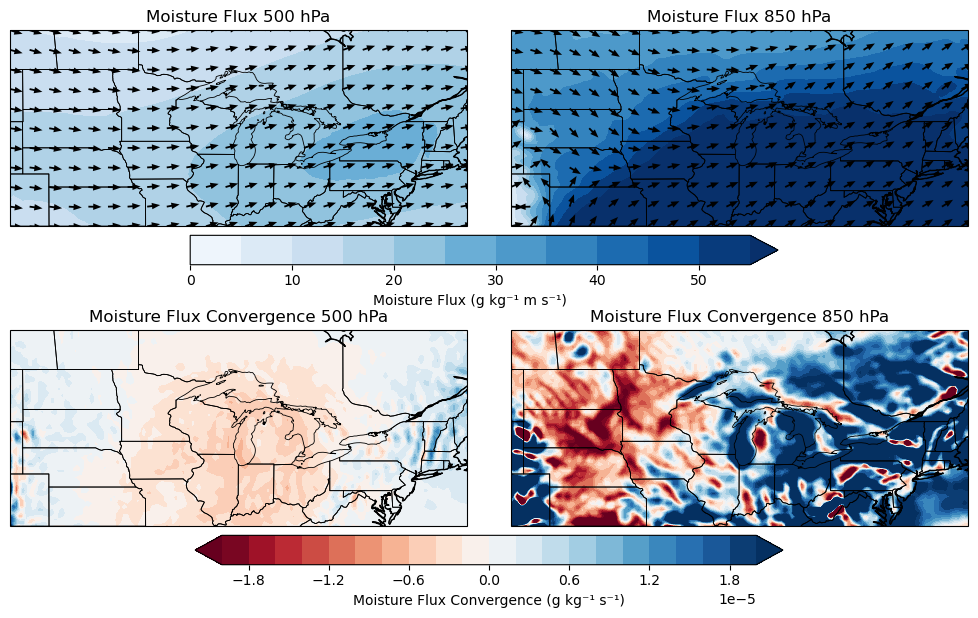

In [14]:
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(2, 2, figsize=(10, 6), subplot_kw={'projection': proj}, constrained_layout=True)

lon = ds_moist_500.longitude
lat = ds_moist_500.latitude

skip = 6
lon_q = lon[::skip]
lat_q = lat[::skip]

ax = axes[0, 0]

cf1 = ax.contourf(lon, lat, MF_500_comp, levels=np.arange(0, 60, 5), cmap='Blues', extend="max", transform=proj)

speed_500 = np.sqrt(MF_u_500_comp**2 + MF_v_500_comp**2)
U500 = (MF_u_500_comp / (speed_500 + 1e-12))[::skip, ::skip]
V500 = (MF_v_500_comp / (speed_500 + 1e-12))[::skip, ::skip]

qv1 = ax.quiver(
    lon_q, lat_q, U500, V500,
    transform=proj, scale=35, 
    width=0.004, headwidth=3.5, headlength=4.5
)

ax.set_title('Moisture Flux 500 hPa')
ax.coastlines(); ax.add_feature(cfeature.STATES, linewidth=0.6)

ax = axes[0, 1]

cf2 = ax.contourf(lon, lat, MF_850_comp, levels=np.arange(0, 60, 5), cmap='Blues', extend="max", transform=proj)

speed_850 = np.sqrt(MF_u_850_comp**2 + MF_v_850_comp**2)
U850 = (MF_u_850_comp / (speed_850 + 1e-12))[::skip, ::skip]
V850 = (MF_v_850_comp / (speed_850 + 1e-12))[::skip, ::skip]

qv2 = ax.quiver(
    lon_q, lat_q, U850, V850,
    transform=proj, scale=35,
    width=0.004, headwidth=3.5, headlength=4.5
)

ax.set_title('Moisture Flux 850 hPa')
ax.coastlines(); ax.add_feature(cfeature.STATES, linewidth=0.6)

axes[0,0].quiverkey(qv1, 0.9, -0.12, 1, 'Direction only', labelpos='E', coordinates='axes')

ax = axes[1, 0]

cf3 = ax.contourf(
    lon, lat, MFC_500_comp,
    levels=np.arange(-0.00002, 0.00002, 0.000002), cmap='RdBu', extend="both", transform=proj
)

ax.set_title('Moisture Flux Convergence 500 hPa')
ax.coastlines(); ax.add_feature(cfeature.STATES, linewidth=0.6)

ax = axes[1, 1]

cf4 = ax.contourf(
    lon, lat, MFC_850_comp,
    levels=np.arange(-0.00002, 0.00002, 0.000002), cmap='RdBu', extend="both", transform=proj
)

ax.set_title('Moisture Flux Convergence 850 hPa')
ax.coastlines(); ax.add_feature(cfeature.STATES, linewidth=0.6)

cbar_mf = fig.colorbar(cf2, ax=axes[0, :], orientation='horizontal', pad=0.03, shrink=0.8)
cbar_mf.set_label('Moisture Flux (g kg⁻¹ m s⁻¹)')

cbar_mfc = fig.colorbar(cf4, ax=axes[1, :], orientation='horizontal', pad=0.03, shrink=0.8)
cbar_mfc.set_label('Moisture Flux Convergence (g kg⁻¹ s⁻¹)')

plt.show()


### **COMPOSITE OF MAPS ANALYSIS**

Moisture flux composites indicate strong southwesterly low-level moisture transport into the Great Lakes, with much larger magnitudes at 850 hPa than at 500 hPa. Correspondingly, moisture flux convergence is strongest at 850 hPa, highlighting the dominant role of low-level moisture convergence in widespread extreme precipitation events.

### 4. EOF

EOF analysis is applied to MF, MF meridional and MFC fields over Domain 2 to extract dominant modes of moisture transport variability.

In [ ]:
# Copied from HW.md module 4 

def _time_as_float(time: xr.DataArray, time_dim: str) -> xr.DataArray:
    t0 = time.isel({time_dim: 0})
    return (time - t0).astype("timedelta64[s]").astype("float64")


def linear_detrend(obj: xr.DataArray | xr.Dataset, time_dim: str = "time") -> xr.DataArray | xr.Dataset:
    t = _time_as_float(obj.coords[time_dim], time_dim)


    def _detrend_da(da: xr.DataArray) -> xr.DataArray:
        da = da.sortby(time_dim).astype("float32")
        if hasattr(da.data, "chunks"):
            da = da.chunk({time_dim: -1})
        mask = da.notnull()
        t_b = t.broadcast_like(da)
        t_mean_valid = t_b.where(mask).mean(time_dim, skipna=True)
        tc = t_b - t_mean_valid
        num = (da * tc).sum(time_dim, skipna=True)
        den = (tc**2).sum(time_dim, skipna=True)
        slope = xr.where(den > 0, num / den, 0.0)
        ybar = da.mean(time_dim, skipna=True)
        trend = slope * (t_b - t_mean_valid) + ybar
        return (da - trend).astype("float32")

    return obj.map(_detrend_da) if isinstance(obj, xr.Dataset) else _detrend_da(obj)

In [ ]:
def compute_eofs(field, n_modes=5, coarsen=4, time_dim='time'):
    # detrend
    detr = linear_detrend(field, time_dim=time_dim)

    detr_plain = detr.metpy.dequantify().astype('float32')

    # coarsen grid
    field_eof = detr_plain.coarsen(
        latitude=coarsen, longitude=coarsen, boundary='trim'
    ).mean()

    # transpose
    field_eof = field_eof.transpose(time_dim, 'latitude', 'longitude').load()

    # weighting
    lat = field_eof['latitude'].values
    lon = field_eof['longitude'].values
    coslat = np.cos(np.deg2rad(lat))
    w2d = np.sqrt(coslat)[:, np.newaxis] * np.ones((len(lat), len(lon)))
    wgts = xr.DataArray(
        w2d,
        coords={'latitude': field_eof['latitude'],
                'longitude': field_eof['longitude']},
        dims=['latitude', 'longitude']
    )

    # EOF solver
    solver = Eof(field_eof, weights=wgts)
    eofs = solver.eofsAsCorrelation(neofs=n_modes)
    pcs  = solver.pcs(npcs=n_modes, pcscaling=1)

    return eofs, pcs, solver


In [16]:
eofs_MFC850, pcs_MFC850, solver_MFC850 = compute_eofs(MFC_850, n_modes=10, coarsen=4)
eofs_MFC500, pcs_MFC500, solver_MFC500 = compute_eofs(MFC_500, n_modes=10, coarsen=4)
eofs_MF850,  pcs_MF850,  solver_MF850  = compute_eofs(MF_850,  n_modes=10, coarsen=4)
eofs_MF500,  pcs_MF500,  solver_MF500  = compute_eofs(MF_500,  n_modes=10, coarsen=4)
eofs_MF850_v, pcs_MF850_v, solver_MF850_v = compute_eofs(MF_v_850, n_modes=10, coarsen=4)
eofs_MF500_v, pcs_MF500_v, solver_MF500_v = compute_eofs(MF_v_500, n_modes=10, coarsen=4)


/tmp/ipykernel_433818/590167542.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


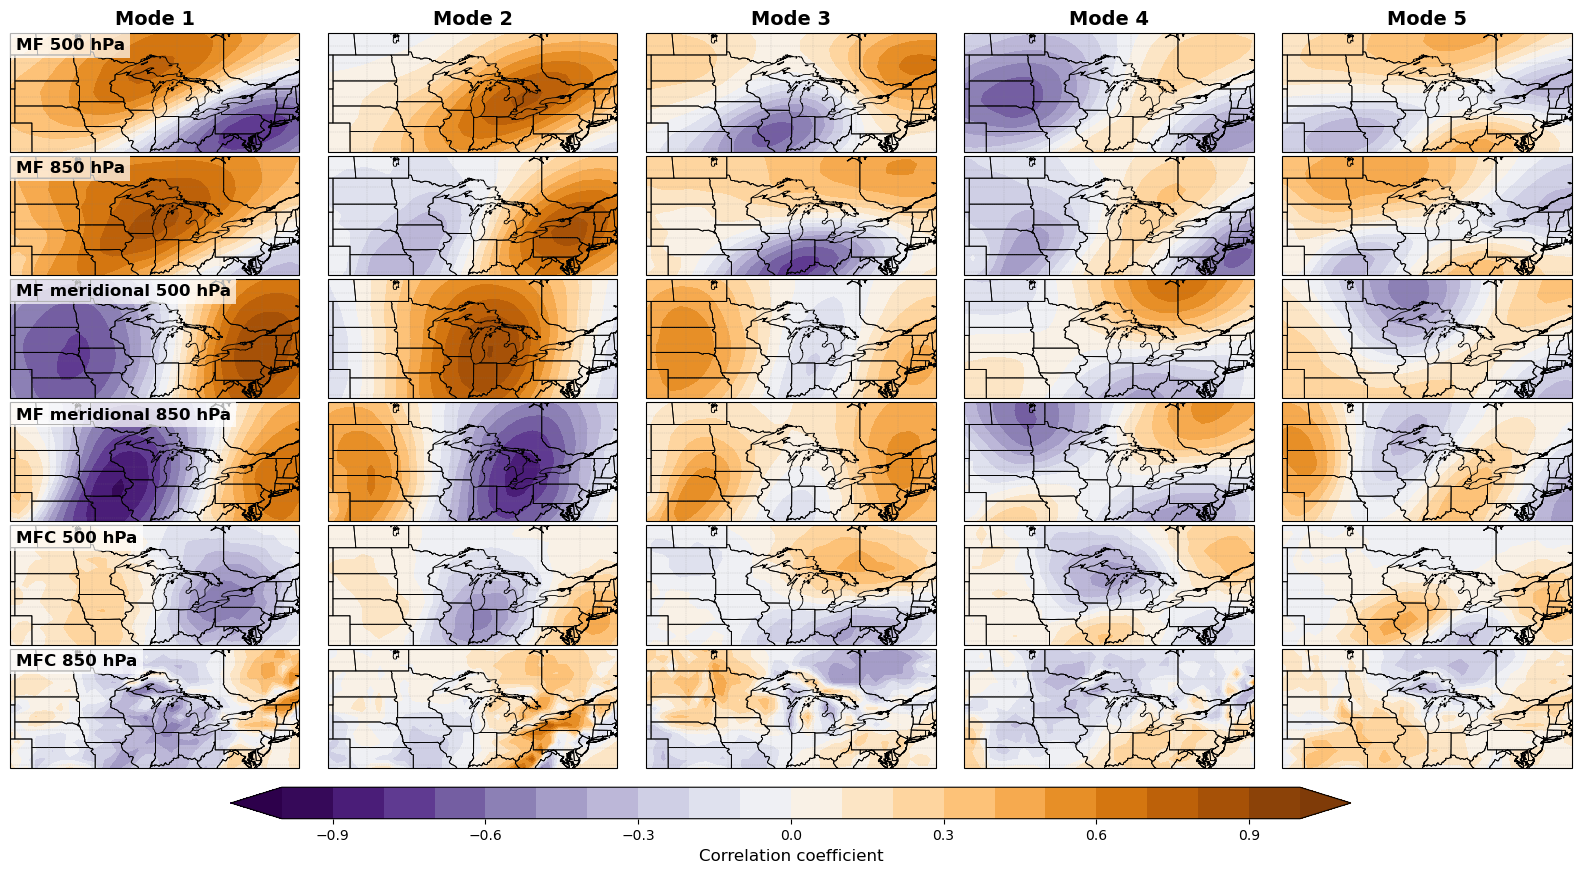

In [18]:
proj = ccrs.PlateCarree(central_longitude=190)

fields     = [eofs_MF500, eofs_MF850, eofs_MF500_v, eofs_MF850_v, eofs_MFC500, eofs_MFC850]
row_labels = ['MF 500 hPa', 'MF 850 hPa', 'MF meridional 500 hPa', 'MF meridional 850 hPa', 'MFC 500 hPa', 'MFC 850 hPa']
n_vars     = len(fields)
n_modes    = 5

fig, axes = plt.subplots(
    n_vars, n_modes, figsize=(16, 9), subplot_kw={'projection': proj}
)

levels = np.linspace(-1, 1, 21)

for r, (eofs, rlabel) in enumerate(zip(fields, row_labels)):
    lon = eofs['longitude']
    lat = eofs['latitude']

    for m in range(n_modes):
        ax = axes[r, m] if n_vars > 1 else axes[m]
        data = eofs.isel(mode=m)

        im = ax.contourf(
            lon, lat, data,
            levels=levels, cmap='PuOr_r', extend='both', transform=ccrs.PlateCarree()
        )
        ax.coastlines(color='k', linewidth=0.6)
        ax.add_feature(cfeature.STATES, linewidth=0.6)

        gl = ax.gridlines(
            draw_labels=False, linewidth=0.3, color='gray',
            alpha=0.4, linestyle='--'
        )

        if r == 0:
            ax.set_title(f'Mode {m+1}', fontweight='bold', fontsize=14)

        if m == 0:
            ax.text(
                0.02, 0.96, rlabel,
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=12, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

cax = fig.add_axes([0.15, 0.04, 0.7, 0.035])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label("Correlation coefficient", fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

### **EOF ANALYSIS**

The leading EOF modes show coherent large-scale moisture transport and convergence patterns over the Great Lakes, with the strongest and most spatially consistent signals at 850 hPa. Lower-level moisture flux and MFC exhibit clearer dipole and convergence structures than at 500 hPa, indicating that low-level moisture dynamics dominate the variability associated with widespread extreme precipitation.

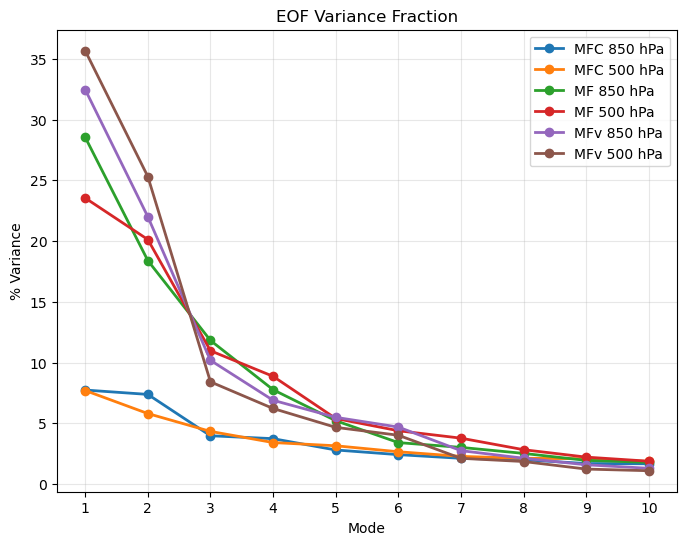

In [19]:
solvers = [
    solver_MFC850, solver_MFC500,
    solver_MF850,  solver_MF500,
    solver_MF850_v, solver_MF500_v
]

labels = [
    "MFC 850 hPa", "MFC 500 hPa",
    "MF 850 hPa",  "MF 500 hPa",
    "MFv 850 hPa", "MFv 500 hPa"
]

plt.figure(figsize=(8, 6))

for solver, lab in zip(solvers, labels):
    varfrac = solver.varianceFraction(neigs=10) * 100
    eof_num = np.arange(1, 11)

    plt.plot(eof_num, varfrac[:10], marker="o", linewidth=2, label=lab)

plt.xlabel("Mode")
plt.ylabel("% Variance")
plt.title("EOF Variance Fraction")
plt.xticks(np.arange(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 5. Regression and Machine Learning

quantify how large-scale moisture transport and convergence patterns over Domain 2 influence the spatial extent of extreme precipitation over Domain 1, we use EOF-based predictors and machine learning regression.

Instead of predicting event vs non-event days, this analysis focuses on event severity, defined by how widespread extreme precipitation is within the target region.

The predictand is defined as the daily number of grid points in Domain 1 exceeding the 13.55 mm/day threshold.

This variable represents the spatial extent of extreme precipitation rather than its intensity, making it well-suited for assessing widespread event predictability.

#### 5.1 Feature Preparation

We use the PC time series from Domain 2 EOF analyses as predictors:

- PCs from MFC850, MFC500
- PCs from MF850, MF500
- PCs from MF_v850, MF_v500

We will use the first 10 modes from each PC set.

In [17]:
X_df = pd.concat([
    pcs_MFC850.to_pandas().add_prefix("MFC850_"),
    pcs_MFC500.to_pandas().add_prefix("MFC500_"),
    pcs_MF850.to_pandas().add_prefix("MF850_"),
    pcs_MF500.to_pandas().add_prefix("MF500_"),
    pcs_MF850_v.to_pandas().add_prefix("MF_v_850_"),
    pcs_MF500_v.to_pandas().add_prefix("MF_v_500_")
], axis=1)

In [18]:
y_gridcount = (tp_daily_mm >= percentile).sum(dim=["latitude","longitude"]).to_pandas()
X, y = X_df.align(y_gridcount, join="inner", axis=0)

#### 5.2 Train-test split

70%: training

30%: testing

In [19]:
split = int(0.7 * len(X))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


#### 5.3 Regression

- Polynomial Regression

Polynomial regression is tested with varying degrees to assess potential nonlinear relationships. Model complexity is selected using cross-validation.

- Random Forest Regression

A Random Forest model is trained using optimized hyperparameters to capture potential nonlinear interactions among EOF modes.

In [ ]:
# Polynomial regression

pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("lr", LinearRegression())
])

param_grid = {
    "poly__degree": [1, 2, 3, 4]
}

gscv_poly = GridSearchCV(
    pipe_poly,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=4
)

gscv_poly.fit(X_train, y_train)

best_poly = gscv_poly.best_estimator_
best_degree = gscv_poly.best_params_["poly__degree"]

y_pred_poly = best_poly.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))


In [ ]:
# Rando Forest Regressor

param_grid_rf = {
    "n_estimators": [300, 600, 900],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [3, 5, 10],
    "max_features": ["sqrt", 0.5]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

gscv_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=4,
    verbose=1
)

gscv_rf.fit(X_train, y_train)

rf_best = gscv_rf.best_estimator_

print("Best RF params:")
print(gscv_rf.best_params_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best RF params:
{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 900}


In [ ]:
y_pred_rf = rf_best.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

In [38]:
summary = pd.DataFrame({
    "Model": [f"Polynomial (deg={best_degree})", "Random Forest"],
    "R²": [r2_poly, r2_rf],
    "RMSE (grids)": [rmse_poly, rmse_rf]
})

summary


,Model,R²,RMSE (grids)
0,Polynomial (deg=1),0.561127,175.958996
1,Random Forest,0.556589,176.866392


In [29]:
if isinstance(y_test, pd.DataFrame):
    y_test_ser = y_test.iloc[:, 0]
else:
    y_test_ser = y_test.copy()
time_test = y_test_ser.index


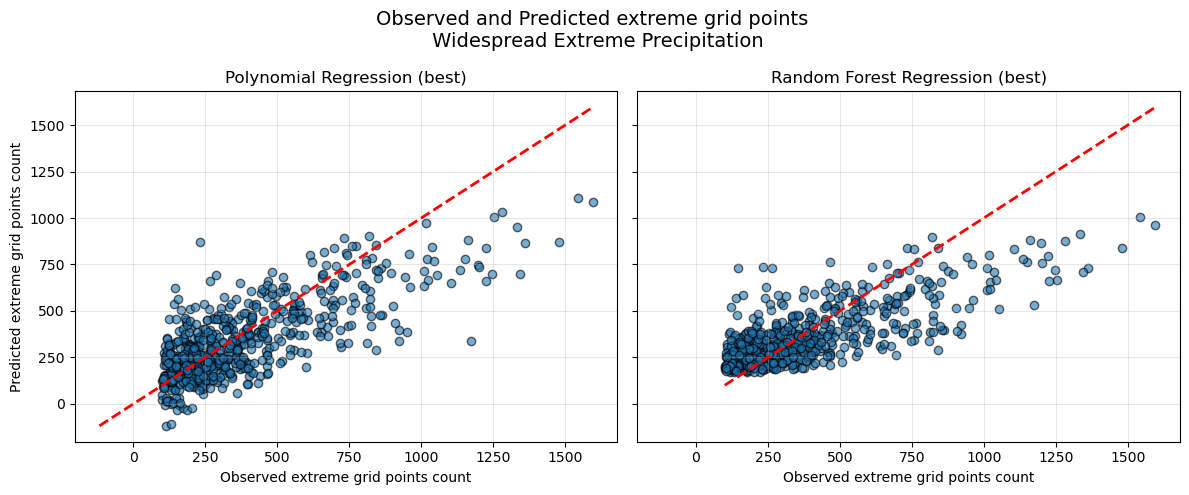

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

preds = [y_pred_poly, y_pred_rf]
titles = ["Polynomial Regression (best)", "Random Forest Regression (best)"]

for ax, y_pred, ttl in zip(axes, preds, titles):
    ax.scatter(y_test_ser.values, y_pred, alpha=0.6, edgecolor="k")

    lims = [
        min(y_test_ser.min(), np.min(y_pred)),
        max(y_test_ser.max(), np.max(y_pred))
    ]
    ax.plot(lims, lims, "r--", linewidth=2)
    ax.set_title(ttl)
    ax.set_xlabel("Observed extreme grid points count")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Predicted extreme grid points count")

plt.suptitle("Observed and Predicted extreme grid points \n Widespread Extreme Precipitation", fontsize=14)
plt.tight_layout()
plt.show()


### **SCATTER PLOT AND TIME SERIES ANALYSIS**

Both models capture the positive relationship between observed and predicted extreme grid counts, but they systematically underestimate the most extreme events, as indicated by deviations below the 1:1 line at high values. Polynomial regression shows slightly better spread and sensitivity to larger extremes, while the random forest predictions are more conservative and clustered around moderate event magnitudes. Further details can be seen in the time series plot below. 

In [35]:
output_notebook()
time_test_dt = pd.to_datetime(time_test)

source = ColumnDataSource(data=dict(
    time=time_test_dt,
    obs=np.asarray(y_test_ser.values, dtype=float),
    poly=np.asarray(y_pred_poly, dtype=float),
    rf=np.asarray(y_pred_rf, dtype=float),
))

hover = HoverTool(
    tooltips=[
        ("Date", "@time{%F}"),
        ("Observed", "@obs{0.0}"),
        ("Polynomial", "@poly{0.0}"),
        ("Random Forest", "@rf{0.0}")
    ],
    formatters={"@time": "datetime"},
    mode="vline"
)

TOOLS = "pan,wheel_zoom,box_zoom,reset,save"
p1 = figure(
    title="Time Series — Polynomial Regression (Test Data)",
    x_axis_type="datetime",
    height=300,
    width=1100,
    tools=TOOLS,
    active_scroll="wheel_zoom",
)
p1.add_tools(hover)

p1.line(
    "time", "obs", source=source,
    line_width=2, color="black",
    legend_label="Observed"
)

p1.line(
    "time", "poly", source=source,
    line_width=2, color="firebrick",
    legend_label="Predicted (Polynomial)"
)

p1.yaxis.axis_label = "Extreme grid points count"
p1.legend.location = "top_left"
p1.legend.click_policy = "hide"

p2 = figure(
    title="Time Series — Random Forest (Test Data)",
    x_axis_type="datetime",
    height=300,
    width=1100,
    tools=TOOLS,
    active_scroll="wheel_zoom",
    x_range=p1.x_range,  # share zoom
)
p2.add_tools(hover)

p2.line(
    "time", "obs", source=source,
    line_width=2, color="black",
    legend_label="Observed"
)

p2.line(
    "time", "rf", source=source,
    line_width=2, color="royalblue",
    legend_label="Predicted (Random Forest)"
)

p2.yaxis.axis_label = "Extreme grid points count"
p2.xaxis.axis_label = "Time"
p2.legend.location = "top_left"
p2.legend.click_policy = "hide"

show(column(p1, p2))


Loading BokehJS ...

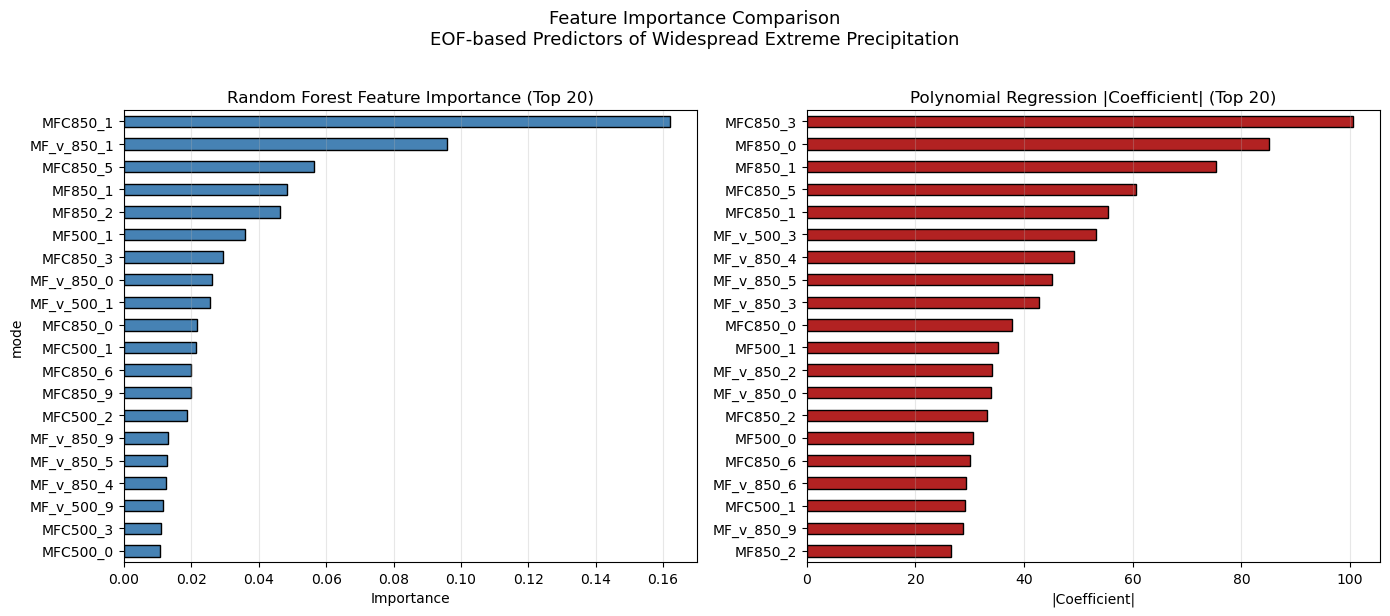

In [36]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

rf_imp = pd.Series(
    rf_best.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

rf_imp.head(top_n).iloc[::-1].plot(
    kind="barh",
    ax=axes[0],
    color="steelblue",
    edgecolor="black"
)

axes[0].set_title(f"Random Forest Feature Importance (Top {top_n})")
axes[0].set_xlabel("Importance")
axes[0].grid(alpha=0.3, axis="x")

poly_step = best_poly.named_steps["poly"]
feat_names = poly_step.get_feature_names_out(X_test.columns)

coef = best_poly.named_steps["lr"].coef_
poly_imp = pd.Series(
    np.abs(coef),
    index=feat_names
).sort_values(ascending=False)

poly_imp.head(top_n).iloc[::-1].plot(
    kind="barh",
    ax=axes[1],
    color="firebrick",
    edgecolor="black"
)

axes[1].set_title(f"Polynomial Regression |Coefficient| (Top {top_n})")
axes[1].set_xlabel("|Coefficient|")
axes[1].grid(alpha=0.3, axis="x")

plt.suptitle(
    "Feature Importance Comparison\nEOF-based Predictors of Widespread Extreme Precipitation",
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()


### **FEATURE IMPORTANCE ANALYSIS**

Both models identify lower-order EOF modes—especially MFC850 and MF850—as the most influential predictors, highlighting the dominant role of large-scale moisture convergence and transport. Differences in ranking between Random Forest and Polynomial regression reflect their distinct sensitivities to nonlinearity versus linear combinations of EOF modes

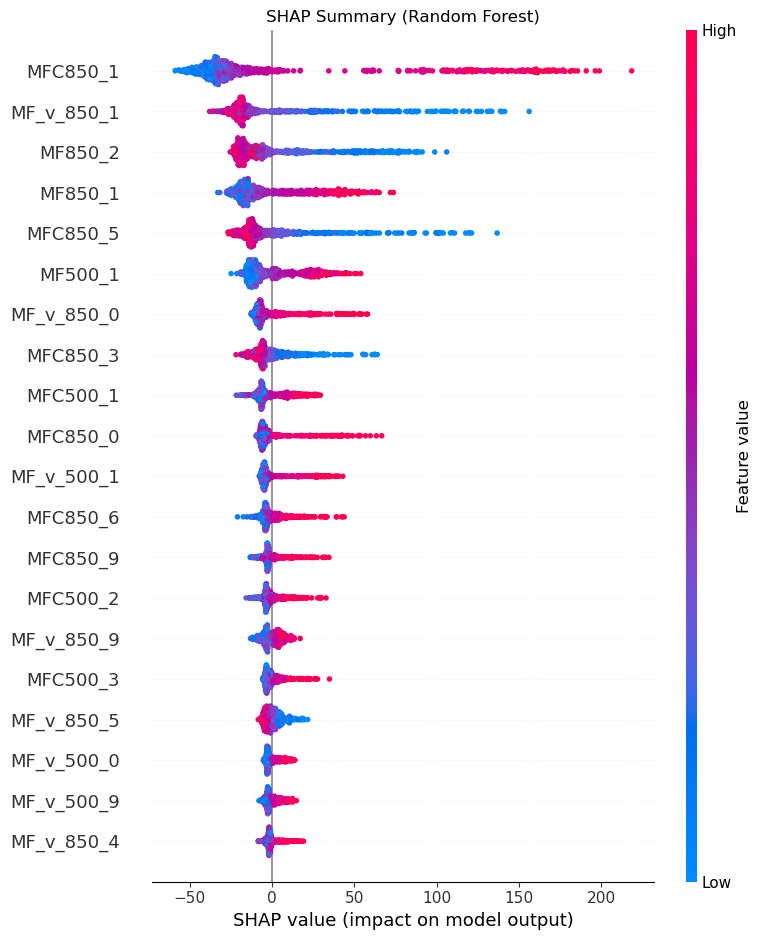

In [37]:
X_shap = X_test.copy()

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary (Random Forest)")
plt.tight_layout()
plt.show()


SHAP results show that high values of lower-order EOF modes—especially MFC850 and MF850—strongly increase the predicted extent of widespread extreme precipitation, while low values suppress it. The asymmetric spread indicates nonlinear responses, with moisture convergence at 850 hPa playing the dominant controlling role.

## ***SUMMARY***

This project shows that widespread extreme precipitation over the Great Lakes is primarily controlled by large-scale moisture convergence, especially at 850 hPa. EOF analysis demonstrates that spatial patterns of moisture flux and convergence, rather than variance-dominant modes alone, are most relevant for extremes.

Regression and machine-learning results indicate that relatively simple, near-linear relationships are sufficient to link moisture dynamics to widespread precipitation events. Feature importance and SHAP analyses consistently highlight low-level MFC as the dominant physical driver, confirming the central role of organized moisture transport in producing regional-scale extreme precipitation.
